# The percentages sum to 101%

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/percent-recomputer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/percent-recomputer/demo.ipynb)

**Day 148 of the FDE portfolio - Percent Recomputer.**

Round three equal rows to one decimal place and the column reads 99.9%. Every row
is correct. The usual reaction is to pick a row and add the missing tenth, and
that reaction is the interesting part, because **choosing which row absorbs it is
an apportionment decision**, the same decision as handing out seats in a
parliament - and apportionment has a proved impossibility at the centre of it.

> **Balinski and Young (1982):** no apportionment method can both stay within the
> quota - every row gets the floor or the ceiling of its exact share - and avoid
> the Alabama paradox, where *raising* the total takes a unit away from a row.

So there is no correct method to switch to. There is a choice between two named
failure modes, and the only wrong move is making it by accident.

**Contents**
1. Nine methods, one hundred and fifty lines
2. The column that does not add up
3. Nine seats, five parties, nine answers
4. The Alabama paradox
5. The population paradox
6. The new-state paradox
7. The scoreboard: no method has an empty row
8. Three failures that belong to percentages, not seats
9. A chart of the whole thing
10. Cross-check against the engine in this repo
11. Try your own table


## 1. Nine methods, one hundred and fifty lines

A percentage column at one decimal place is an apportionment of **1000 units** -
tenths of a point. Seats in a parliament are an apportionment of 9, or 100. Same
problem, same code below.

Two families:

* **independent rounding** - round each row on its own. The only family that can
  fail to sum, and the one every dashboard ships.
* **apportionment** - hand out the whole budget deliberately. Always sums. The
  methods differ in *who they favour*, which is a policy choice, not a rounding
  detail.

Exact shares are computed with `Fraction`, never floats: the quota is the one
unarguable number in the file and it should not be the first thing to lose
precision.


In [1]:
from __future__ import annotations

import math
from fractions import Fraction
from typing import Callable, Dict, List, Optional, Sequence, Tuple

Table = Tuple[Tuple[str, float], ...]   # ((label, value), ...)


def quotas(rows: Table, units: int) -> List[Fraction]:
    """Exact share of the budget, per row. Sums to `units` exactly."""
    total = sum(Fraction(str(v)) for _, v in rows)
    if total == 0:
        return [Fraction(0) for _ in rows]
    return [Fraction(str(v)) * units / total for _, v in rows]


# --- family 1: independent rounding ---------------------------------------
def naive_half_up(rows: Table, units: int) -> List[int]:
    """Round each row half away from zero - the SQL and spreadsheet convention."""
    return [int(math.floor(q + Fraction(1, 2))) for q in quotas(rows, units)]


def naive_half_even(rows: Table, units: int) -> List[int]:
    """Round each row half to even - what Python's own `round` does, and pandas."""
    out = []
    for q in quotas(rows, units):
        f, rem = math.floor(q), q - math.floor(q)
        if rem > Fraction(1, 2):
            out.append(int(f) + 1)
        elif rem < Fraction(1, 2):
            out.append(int(f))
        else:
            out.append(int(f) if int(f) % 2 == 0 else int(f) + 1)
    return out


# --- family 2: apportionment ----------------------------------------------
def largest_remainder(rows: Table, units: int) -> List[int]:
    """Hamilton / Hare-Niemeyer: floor everybody, hand the rest to the top remainders.

    Never leaves the quota. Suffers the Alabama paradox. Ties are broken by input
    order, which is a convention rather than a rule.
    """
    q = quotas(rows, units)
    alloc = [int(math.floor(x)) for x in q]
    left = units - sum(alloc)
    order = sorted(range(len(q)), key=lambda i: (-(q[i] - alloc[i]), i))
    for i in order[:max(left, 0)]:
        alloc[i] += 1
    return alloc


def highest_averages(rows: Table, units: int, priority: Callable[[float, int], float],
                     min_one: bool = False) -> Optional[List[int]]:
    """The divisor engine: award one unit at a time to the highest priority row.

    `priority(value, already_awarded)` is the entire difference between D'Hondt,
    Sainte-Lague, Adams and Huntington-Hill.
    """
    alloc = [0] * len(rows)
    live = [i for i, (_, v) in enumerate(rows) if v > 0]
    if not live:
        return alloc
    if min_one and units < len(live):
        return None  # this method guarantees everyone a unit and cannot here
    for _ in range(units):
        best, best_p = None, None
        for i in live:
            p = priority(rows[i][1], alloc[i])
            if best_p is None or p > best_p:
                best, best_p = i, p
        alloc[best] += 1
    return alloc


def jefferson(rows: Table, units: int):      # D'Hondt: rounds down, favours the big
    return highest_averages(rows, units, lambda v, a: v / (a + 1))


def webster(rows: Table, units: int):        # Sainte-Lague: nearest, least biased
    return highest_averages(rows, units, lambda v, a: v / (2 * a + 1))


def adams(rows: Table, units: int):          # rounds up, favours the small
    return highest_averages(rows, units, lambda v, a: math.inf if a == 0 else v / a, min_one=True)


def huntington_hill(rows: Table, units: int):  # geometric mean; the US House method
    return highest_averages(rows, units,
                            lambda v, a: math.inf if a == 0 else v / math.sqrt(a * (a + 1)),
                            min_one=True)


# --- family 3: the hacks ---------------------------------------------------
def last_row_dump(rows: Table, units: int) -> List[int]:
    """Round naively, then push the entire residual onto the last row, unmarked."""
    a = naive_half_up(rows, units)
    a[-1] += units - sum(a)
    return a


def largest_row_dump(rows: Table, units: int) -> List[int]:
    """Same, onto the biggest row - where it is least visible as a share of that row."""
    a = naive_half_up(rows, units)
    i = max(range(len(rows)), key=lambda k: rows[k][1])
    a[i] += units - sum(a)
    return a


METHODS = {"naive_half_up": naive_half_up, "naive_half_even": naive_half_even,
           "largest_remainder": largest_remainder, "jefferson_dhondt": jefferson,
           "webster_sainte_lague": webster, "adams": adams,
           "huntington_hill": huntington_hill, "last_row_dump": last_row_dump,
           "largest_row_dump": largest_row_dump}
print(f"{len(METHODS)} methods defined:", ", ".join(METHODS))

9 methods defined: naive_half_up, naive_half_even, largest_remainder, jefferson_dhondt, webster_sainte_lague, adams, huntington_hill, last_row_dump, largest_row_dump


## 2. The column that does not add up

Three equal rows, one decimal place. `33.3 + 33.3 + 33.3 = 99.9`.

Rounding is a **per-row** operation and adding to 100 is a **joint** constraint on
all rows at once. The first cannot preserve the second, so no improvement to the
rounding function fixes this - only a method that hands out the whole budget on
purpose.


In [2]:
THIRDS: Table = (("alpha", 1000), ("beta", 1000), ("gamma", 1000))
UNITS_1DP = 1000   # tenths of a point


def show(rows: Table, units: int = UNITS_1DP, scale: Optional[int] = None) -> None:
    """Print every method's answer for one table."""
    div = scale if scale is not None else (10 if units == UNITS_1DP else 1)
    suffix = "%" if units == UNITS_1DP else ""
    print(f"  {'method':<22} {'allocation':<34} {'sums':>5}")
    for name, fn in METHODS.items():
        a = fn(rows, units)
        if a is None:
            print(f"  {name:<22} {'no answer for this table':<34} {'-':>5}")
            continue
        shown = ", ".join(f"{x / div:g}{suffix}" for x in a)
        print(f"  {name:<22} {shown:<34} {'yes' if sum(a) == units else 'NO':>5}")
    q = quotas(rows, units)
    print(f"  {'exact shares':<22} " + ", ".join(f"{float(x) / div:.4g}{suffix}" for x in q))


show(THIRDS)

  method                 allocation                          sums
  naive_half_up          33.3%, 33.3%, 33.3%                   NO
  naive_half_even        33.3%, 33.3%, 33.3%                   NO
  largest_remainder      33.4%, 33.3%, 33.3%                  yes
  jefferson_dhondt       33.4%, 33.3%, 33.3%                  yes
  webster_sainte_lague   33.4%, 33.3%, 33.3%                  yes
  adams                  33.4%, 33.3%, 33.3%                  yes
  huntington_hill        33.4%, 33.3%, 33.3%                  yes
  last_row_dump          33.3%, 33.3%, 33.4%                  yes
  largest_row_dump       33.4%, 33.3%, 33.3%                  yes
  exact shares           33.33%, 33.33%, 33.33%


## 3. Nine seats, five parties, nine answers

Now the same code on a real allocation: 9 council seats from five vote counts.

Watch the first party. Its exact share is 3.97 seats, and across the methods it is
awarded **3, 4 or 5** of the 9. Not a tenth of a point - a fifth of the council.
D'Hondt gives it 5, which is more than the ceiling of its own share: a **quota
violation**, and the reason D'Hondt is the method large parties lobby for.


In [3]:
COUNCIL: Table = (("blue", 5709), ("red", 2908), ("green", 2492),
                  ("yellow", 920), ("grey", 911))
SEATS = 9

show(COUNCIL, SEATS)


def quota_violations(rows: Table, units: int, alloc: Sequence[int]) -> List[Tuple[str, int, float]]:
    """Rows awarded outside [floor(share), ceil(share)] - the fairness readers assume."""
    out = []
    for (label, _), a, q in zip(rows, alloc, quotas(rows, units)):
        if a < math.floor(q) or a > math.ceil(q):
            out.append((label, a, float(q)))
    return out


print()
for name, fn in METHODS.items():
    a = fn(COUNCIL, SEATS)
    if a is None or sum(a) != SEATS:
        continue
    for label, awarded, q in quota_violations(COUNCIL, SEATS, a):
        print(f"  {name}: {label} awarded {awarded} against an exact share of {q:.3f} "
              f"({awarded - q:+.3f})")

blue = sorted({fn(COUNCIL, SEATS)[0] for fn in METHODS.values() if fn(COUNCIL, SEATS)})
print(f"\n  blue is awarded {blue} seats of {SEATS}, depending on which correct method ran")

  method                 allocation                          sums
  naive_half_up          4, 2, 2, 1, 1                         NO
  naive_half_even        4, 2, 2, 1, 1                         NO
  largest_remainder      4, 2, 2, 1, 0                        yes
  jefferson_dhondt       5, 2, 2, 0, 0                        yes
  webster_sainte_lague   3, 2, 2, 1, 1                        yes
  adams                  3, 2, 2, 1, 1                        yes
  huntington_hill        3, 2, 2, 1, 1                        yes
  last_row_dump          4, 2, 2, 1, 0                        yes
  largest_row_dump       3, 2, 2, 1, 1                        yes
  exact shares           3.971, 2.023, 1.733, 0.6399, 0.6336

  jefferson_dhondt: blue awarded 5 against an exact share of 3.971 (+1.029)

  blue is awarded [3, 4, 5] seats of 9, depending on which correct method ran


## 4. The Alabama paradox

A committee of 7 seats, allocated by headcount, grows to 8. The smallest team
loses its only seat.

Named for the 1880 US census: Alabama had 8 seats in a 299-seat House and 7 in a
300-seat House. The values found below were located by exhaustive search over
small integer tables, not copied from a textbook - the search is in `evidence.py`
in the repository.


In [4]:
COMMITTEE: Table = (("engineering", 22), ("operations", 39), ("legal", 4))


def alabama(rows: Table, units: int, method: str) -> List[Tuple[str, int, int]]:
    """Rows that lose a unit when the budget goes UP by one."""
    before, after = METHODS[method](rows, units), METHODS[method](rows, units + 1)
    return [(rows[i][0], before[i], after[i]) for i in range(len(rows)) if after[i] < before[i]]


print(f"  {'row':<14} {'7 seats':>8} {'8 seats':>8} {'share at 7':>11} {'share at 8':>11}")
b, a = largest_remainder(COMMITTEE, 7), largest_remainder(COMMITTEE, 8)
q7, q8 = quotas(COMMITTEE, 7), quotas(COMMITTEE, 8)
for i, (label, _) in enumerate(COMMITTEE):
    print(f"  {label:<14} {b[i]:>8} {a[i]:>8} {float(q7[i]):>11.3f} {float(q8[i]):>11.3f}")
print(f"\n  largest_remainder: {alabama(COMMITTEE, 7, 'largest_remainder')}")
for m in ("jefferson_dhondt", "webster_sainte_lague", "huntington_hill"):
    print(f"  {m:<22} {alabama(COMMITTEE, 7, m) or 'no paradox'}")

  row             7 seats  8 seats  share at 7  share at 8
  engineering           2        3       2.369       2.708
  operations            4        5       4.200       4.800
  legal                 1        0       0.431       0.492

  largest_remainder: [('legal', 1, 0)]
  jefferson_dhondt       no paradox
  webster_sainte_lague   no paradox
  huntington_hill        no paradox


## 5. The population paradox

Two regions grow. The one that grows **faster** loses a seat to the one that grows
slower. Same method, same seat count, nothing else changed.

Every divisor method is immune to this by construction, and largest remainder is
not. That is the other half of the Balinski-Young trade: the method that respects
the quota is the method that can punish growth.


In [5]:
BEFORE: Table = (("north", 302), ("east", 25), ("south", 259))
AFTER: Table = (("north", 434), ("east", 27), ("south", 325))
SEATS_13 = 13


def population_paradox(before: Table, after: Table, units: int, method: str):
    """(loser, gainer, loser_growth, gainer_growth) where the faster grower lost."""
    a0, a1 = METHODS[method](before, units), METHODS[method](after, units)
    rate = [after[i][1] / before[i][1] for i in range(len(before))]
    out = []
    for i in range(len(before)):
        for j in range(len(before)):
            if i != j and rate[i] > rate[j] and a1[i] < a0[i] and a1[j] > a0[j]:
                out.append((before[i][0], before[j][0], rate[i], rate[j]))
    return out


a0, a1 = largest_remainder(BEFORE, SEATS_13), largest_remainder(AFTER, SEATS_13)
print(f"  {'row':<8} {'before':>7} {'after':>7} {'growth':>8} {'seats':>7} {'seats':>7}")
for i, (label, v0) in enumerate(BEFORE):
    v1 = AFTER[i][1]
    print(f"  {label:<8} {v0:>7} {v1:>7} {v1 / v0 - 1:>7.1%} {a0[i]:>7} {a1[i]:>7}")
for loser, gainer, rl, rg in population_paradox(BEFORE, AFTER, SEATS_13, "largest_remainder"):
    print(f"\n  {loser} grew {rl - 1:.1%} and LOST a seat; {gainer} grew {rg - 1:.1%} and gained one")
for m in ("jefferson_dhondt", "webster_sainte_lague", "huntington_hill", "adams"):
    print(f"  {m:<22} {population_paradox(BEFORE, AFTER, SEATS_13, m) or 'immune'}")

  row       before   after   growth   seats   seats
  north        302     434   43.7%       7       7
  east          25      27    8.0%       0       1
  south        259     325   25.5%       6       5

  south grew 25.5% and LOST a seat; east grew 8.0% and gained one
  jefferson_dhondt       immune
  webster_sainte_lague   immune
  huntington_hill        immune
  adams                  immune


## 6. The new-state paradox

A new row joins, bringing its own fair share of extra units. Two existing rows -
whose values did not change and whose share of each other did not change - swap a
unit.

Named for Oklahoma joining the Union in 1907: the House grew by the seats Oklahoma
was owed, and New York still lost one to Maine.


In [6]:
NEWCOMER: Table = (("west", 122), ("centre", 57), ("hills", 40), ("coast", 104))
SEATS_19 = 19
NEW_ROW = ("newtown", 103)
EXTRA = 6

before = largest_remainder(NEWCOMER, SEATS_19)
after = largest_remainder(NEWCOMER + (NEW_ROW,), SEATS_19 + EXTRA)
print(f"  {'row':<10} {'before':>7} {'after':>7}")
for i, (label, _) in enumerate(NEWCOMER):
    flag = "  <-- moved" if after[i] != before[i] else ""
    print(f"  {label:<10} {before[i]:>7} {after[i]:>7}{flag}")
print(f"  {NEW_ROW[0]:<10} {'-':>7} {after[-1]:>7}")
print("\n  centre and hills swapped a seat because a fifth row joined.")

  row         before   after
  west             7       7
  centre           4       3  <-- moved
  hills            2       3  <-- moved
  coast            6       6
  newtown          -       6

  centre and hills swapped a seat because a fifth row joined.


## 7. The scoreboard: no method has an empty row

Run every method over every table and count three failures:

* **fails to sum** - the column does not reach the budget
* **quota** - some row is awarded outside the floor-to-ceiling window of its share
* **alabama** - adding one unit to the budget takes one away from a row

Independent rounding fails to sum. Largest remainder is the only method that never
leaves the quota and the only one with the paradox. The divisor methods are the
mirror image. **No column is empty**, and that is not a limitation of this
notebook - it is the theorem.


In [7]:
CORPUS: Dict[str, Tuple[Table, int]] = {
    "quarters": ((("north", 250), ("east", 250), ("south", 250), ("west", 250)), UNITS_1DP),
    "thirds": (THIRDS, UNITS_1DP),
    "instances": ((("t3.nano", 100), ("t3.micro", 100), ("t3.small", 200),
                   ("t3.medium", 400), ("t3.large", 800)), UNITS_1DP),
    "traffic": ((("organic", 48213), ("direct", 21877), ("paid-search", 12044),
                 ("referral", 6231), ("social", 3187), ("email", 1502),
                 ("affiliate", 214), ("qr-print", 29)), UNITS_1DP),
    "survey-n7": ((("yes", 3), ("no", 3), ("unsure", 1)), UNITS_1DP),
    "regions-grouped": ((("london", 2133), ("manchester", 2684), ("leeds", 1045),
                         ("berlin", 3444), ("munich", 4122), ("hamburg", 1469)), UNITS_1DP),
    "committee-7": (COMMITTEE, 7),
    "census-after": (AFTER, SEATS_13),
    "newcomer-19": (NEWCOMER, SEATS_19),
    "council-9": (COUNCIL, SEATS),
    "queues-13": ((("billing", 57), ("api", 90), ("mobile", 18), ("web", 19),
                   ("platform", 395)), 13),
    "shifts-17": ((("sre-eu", 2), ("sre-apac", 8), ("sre-us", 190), ("core", 300)), 17),
    "shortlist-3": ((("ana", 41), ("ben", 33), ("cai", 22), ("dee", 18), ("eli", 9)), 3),
}

DIVISORS = ("largest_remainder", "jefferson_dhondt", "webster_sainte_lague",
            "adams", "huntington_hill")
scoreboard = {}
for name, fn in METHODS.items():
    s = q = al = 0
    for rows, units in CORPUS.values():
        a = fn(rows, units)
        if a is None:
            s += 1
            continue
        if sum(a) != units:
            s += 1
        if quota_violations(rows, units, a):
            q += 1
        if name in DIVISORS and alabama(rows, units, name):
            al += 1
    scoreboard[name] = [s, q, al]

print(f"  {'method':<22} {'fails to sum':>12} {'quota':>6} {'alabama':>8}")
for name, (s, q, al) in scoreboard.items():
    print(f"  {name:<22} {s:>12} {q:>6} {al:>8}")
clean = [m for m, v in scoreboard.items() if sum(v) == 0]
print(f"\n  methods with no failure anywhere in {len(CORPUS)} tables: {clean or 'none'}")

  method                 fails to sum  quota  alabama
  naive_half_up                    10      0        0
  naive_half_even                  10      0        0
  largest_remainder                 0      0        2
  jefferson_dhondt                  0      4        0
  webster_sainte_lague              0      1        0
  adams                             1      4        0
  huntington_hill                   1      1        0
  last_row_dump                     0      2        0
  largest_row_dump                  0      3        0

  methods with no failure anywhere in 13 tables: none


## 8. Three failures that belong to percentages, not to seats

Seats are integers by nature. A percentage column adds three problems of its own,
and none of them is a rounding question.

**a) The precision does not exist.** Seven respondents. A share can only be a
multiple of 100/7 = 14.286 points. Printing `42.9%` implies a measurement to one
decimal place from a sample of seven - `3/7` dressed up as precision.

**b) A grouped table cannot be consistent at both levels.** Rows must sum to
subtotals, subtotals to the grand total, and each printed number must be a
rounding of its own share. Three constraints, one set of integers, usually no
solution: pick the level allowed to disagree and say so.

**c) A signed base has no shares.** One negative line and "percent of total" can
exceed 100%, go negative, and reorder if the sign flips. The honest answer is to
refuse, not to divide.


In [8]:
# a) precision that the denominator cannot carry
survey, units = CORPUS["survey-n7"]
n = int(sum(v for _, v in survey))
step = 100 / n
print(f"  denominator {n}: the only shares that exist are multiples of {step:.4g} points")
print(f"  {[round(k * step, 3) for k in range(n + 1)]}")
print(f"  the column prints {[f'{x / 10:.1f}%' for x in naive_half_up(survey, units)]}\n")

# b) a grouped table, rounded at both levels
grouped, units = CORPUS["regions-grouped"]
GROUP = {"london": "UK", "manchester": "UK", "leeds": "UK",
         "berlin": "DE", "munich": "DE", "hamburg": "DE"}
rows_alloc = largest_remainder(grouped, units)
per_group: Dict[str, int] = {}
for (label, _), a in zip(grouped, rows_alloc):
    per_group[GROUP[label]] = per_group.get(GROUP[label], 0) + a
group_values: Dict[str, float] = {}
for label, v in grouped:
    group_values[GROUP[label]] = group_values.get(GROUP[label], 0.0) + v
group_rows = tuple(group_values.items())
group_alloc = largest_remainder(group_rows, units)
for (g, _), own in zip(group_rows, group_alloc):
    flag = "  <-- clash" if per_group[g] != own else ""
    print(f"  group {g}: rows sum to {per_group[g] / 10:.1f}%, its own rounded share "
          f"is {own / 10:.1f}%{flag}")

# c) a signed base
pnl: Table = (("subscriptions", 820000), ("services", 240000),
              ("hardware", -95000), ("other", 15000))
total = sum(v for _, v in pnl)
print(f"\n  P&L total {total:,.0f}; shares as printed by a naive percent:")
for label, v in pnl:
    print(f"    {label:<14} {100 * v / total:>8.1f}%")
print("  the negative line makes the column meaningless, and it still renders")

  denominator 7: the only shares that exist are multiples of 14.29 points
  [0.0, 14.286, 28.571, 42.857, 57.143, 71.429, 85.714, 100.0]
  the column prints ['42.9%', '42.9%', '14.3%']

  group UK: rows sum to 39.3%, its own rounded share is 39.4%  <-- clash
  group DE: rows sum to 60.7%, its own rounded share is 60.6%  <-- clash

  P&L total 980,000; shares as printed by a naive percent:
    subscriptions      83.7%
    services           24.5%
    hardware           -9.7%
    other               1.5%
  the negative line makes the column meaningless, and it still renders


## 9. A chart of the whole thing

Left: the nine methods on the council table, with the floor-to-ceiling band of
each party's exact share - a dot outside the band is a quota violation. Right: the
scoreboard, where no method has an empty row.


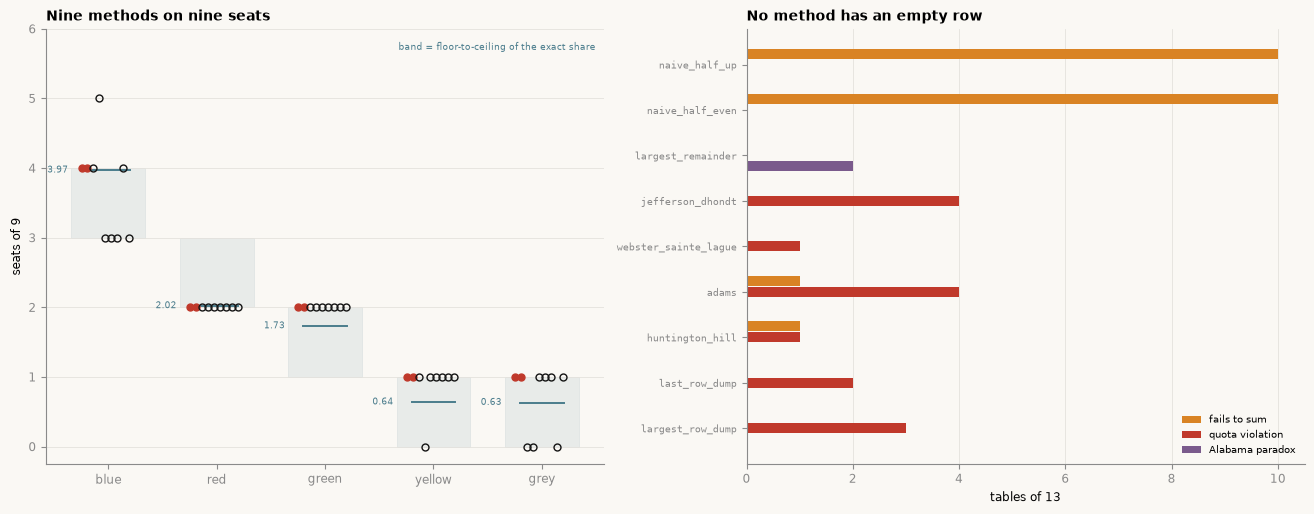

In [9]:
import matplotlib.pyplot as plt
import numpy as np

INK, MUTED, GRID, PAPER = "#141414", "#8a8a8a", "#e4e2dd", "#faf8f4"
RED, ORANGE, BLUE, PURPLE = "#c0392b", "#d98324", "#4a7c8c", "#7a5a8c"
plt.rcParams.update({"font.size": 8.5, "figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "savefig.facecolor": PAPER, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "xtick.color": MUTED, "ytick.color": MUTED})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 5.2))

labels = [label for label, _ in COUNCIL]
q = [float(x) for x in quotas(COUNCIL, SEATS)]
x = np.arange(len(labels))
names = list(METHODS)
for i, name in enumerate(names):
    a = METHODS[name](COUNCIL, SEATS)
    if a is None:
        continue
    ok = sum(a) == SEATS
    ax1.plot(x + (i - len(names) / 2) * 0.055, a, marker="o", ms=5, lw=0,
             mfc="none" if ok else RED, color=INK if ok else RED, zorder=3)
for xi, qi in zip(x, q):
    ax1.add_patch(plt.Rectangle((xi - 0.34, np.floor(qi)), 0.68,
                                max(np.ceil(qi) - np.floor(qi), 0.001),
                                facecolor=BLUE, alpha=0.10, edgecolor=BLUE, lw=0.6, zorder=0))
    ax1.plot([xi - 0.2, xi + 0.2], [qi, qi], color=BLUE, lw=1.4, zorder=2)
    ax1.text(xi - 0.37, qi, f"{qi:.2f}", fontsize=6.6, color=BLUE, ha="right", va="center")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel(f"seats of {SEATS}")
ax1.set_yticks(range(0, 7))
ax1.grid(axis="y", color=GRID, lw=0.6)
ax1.set_axisbelow(True)
ax1.set_title("Nine methods on nine seats", loc="left", fontsize=10, fontweight="bold")
ax1.text(0.985, 0.97, "band = floor-to-ceiling of the exact share", transform=ax1.transAxes,
         fontsize=6.8, color=BLUE, ha="right", va="top")

ys = np.arange(len(scoreboard))
ax2.barh(ys - 0.24, [v[0] for v in scoreboard.values()], height=0.22, color=ORANGE,
         label="fails to sum")
ax2.barh(ys, [v[1] for v in scoreboard.values()], height=0.22, color=RED, label="quota violation")
ax2.barh(ys + 0.24, [v[2] for v in scoreboard.values()], height=0.22, color=PURPLE,
         label="Alabama paradox")
ax2.set_yticks(ys)
ax2.set_yticklabels(scoreboard.keys(), fontsize=7, fontfamily="monospace")
ax2.invert_yaxis()
ax2.set_xlabel(f"tables of {len(CORPUS)}")
ax2.legend(frameon=False, fontsize=7, loc="lower right")
ax2.grid(axis="x", color=GRID, lw=0.6)
ax2.set_axisbelow(True)
ax2.set_title("No method has an empty row", loc="left", fontsize=10, fontweight="bold")

fig.tight_layout()
fig.savefig("percent_notebook.png", dpi=150)
plt.show()

## 10. Cross-check against the engine in this repo

The methods above were written independently of `percentages.py`. The values below
were printed by the engine when this notebook was generated, so a drift between
the two implementations fails an assertion here rather than producing two
documents that disagree.


In [10]:
PINNED = {
    "council": {
        "naive_half_up": [
            4,
            2,
            2,
            1,
            1
        ],
        "naive_half_even": [
            4,
            2,
            2,
            1,
            1
        ],
        "largest_remainder": [
            4,
            2,
            2,
            1,
            0
        ],
        "jefferson_dhondt": [
            5,
            2,
            2,
            0,
            0
        ],
        "webster_sainte_lague": [
            3,
            2,
            2,
            1,
            1
        ],
        "adams": [
            3,
            2,
            2,
            1,
            1
        ],
        "huntington_hill": [
            3,
            2,
            2,
            1,
            1
        ],
        "last_row_dump": [
            4,
            2,
            2,
            1,
            0
        ],
        "largest_row_dump": [
            3,
            2,
            2,
            1,
            1
        ]
    },
    "committee_7": [
        2,
        4,
        1
    ],
    "census_before": [
        7,
        0,
        6
    ],
    "census_after": [
        7,
        1,
        5
    ],
    "verdicts": {
        "consistent": 1,
        "residual": 2,
        "contested": 10,
        "undefined": 2
    },
    "scoreboard": {
        "naive_half_up": [
            10,
            0,
            0
        ],
        "naive_half_even": [
            10,
            0,
            0
        ],
        "largest_remainder": [
            0,
            0,
            2
        ],
        "jefferson_dhondt": [
            0,
            4,
            0
        ],
        "webster_sainte_lague": [
            0,
            1,
            0
        ],
        "adams": [
            1,
            4,
            0
        ],
        "huntington_hill": [
            1,
            1,
            0
        ],
        "last_row_dump": [
            0,
            2,
            0
        ],
        "largest_row_dump": [
            0,
            3,
            0
        ]
    }
}

for name, fn in METHODS.items():
    mine = fn(COUNCIL, SEATS)
    expected = PINNED["council"][name]
    assert mine == expected, (name, mine, expected)
print(f"  all {len(METHODS)} methods match the engine on the council table")

assert largest_remainder(COMMITTEE, 7) == PINNED["committee_7"]
assert largest_remainder(BEFORE, SEATS_13) == PINNED["census_before"]
assert largest_remainder(AFTER, SEATS_13) == PINNED["census_after"]
print("  the three paradox tables match the engine")

assert scoreboard == PINNED["scoreboard"], (scoreboard, PINNED["scoreboard"])
print(f"  the scoreboard matches the engine: {PINNED['scoreboard']['largest_remainder']} "
      f"for largest_remainder (sum, quota, alabama)")
print(f"\n  engine verdicts over its 15-table corpus: {PINNED['verdicts']}")
print("  two independent implementations, same numbers.")

  all 9 methods match the engine on the council table
  the three paradox tables match the engine
  the scoreboard matches the engine: [0, 0, 2] for largest_remainder (sum, quota, alabama)

  engine verdicts over its 15-table corpus: {'consistent': 1, 'residual': 2, 'contested': 10, 'undefined': 2}
  two independent implementations, same numbers.


## 11. Try your own table

Paste the counts behind a percentage column you have shipped. The interesting
output is not the column - it is whether two defensible methods disagree about it,
and by how much.


In [11]:
MINE: Table = (
    ("enterprise", 412),
    ("mid-market", 318),
    ("smb", 265),
    ("self-serve", 5),      # try deleting this row and watch the others move
)
UNITS = UNITS_1DP          # 1000 = one decimal place; use 100 for whole numbers

show(MINE, UNITS)
allocs = {n: fn(MINE, UNITS) for n, fn in METHODS.items() if fn(MINE, UNITS) is not None}
summing = {n: a for n, a in allocs.items() if sum(a) == UNITS}
print()
for i, (label, _) in enumerate(MINE):
    vals = sorted({a[i] for a in summing.values()})
    if len(vals) > 1:
        span = f"{vals[0] / 10:g}% to {vals[-1] / 10:g}%"
        print(f"  {label:<12} methods disagree: {span}  ({vals[-1] - vals[0]} tenths of a point)")
    else:
        print(f"  {label:<12} every method agrees on {vals[0] / 10:g}%")
naive = naive_half_up(MINE, UNITS)
print(f"\n  independent rounding sums to {sum(naive) / 10:g}% "
      f"({sum(naive) - UNITS:+d} tenths)")
print(f"  quota violations by D'Hondt: {quota_violations(MINE, UNITS, jefferson(MINE, UNITS))}")

  method                 allocation                          sums
  naive_half_up          41.2%, 31.8%, 26.5%, 0.5%            yes
  naive_half_even        41.2%, 31.8%, 26.5%, 0.5%            yes
  largest_remainder      41.2%, 31.8%, 26.5%, 0.5%            yes
  jefferson_dhondt       41.2%, 31.8%, 26.5%, 0.5%            yes
  webster_sainte_lague   41.2%, 31.8%, 26.5%, 0.5%            yes
  adams                  41.2%, 31.8%, 26.5%, 0.5%            yes
  huntington_hill        41.2%, 31.8%, 26.5%, 0.5%            yes
  last_row_dump          41.2%, 31.8%, 26.5%, 0.5%            yes
  largest_row_dump       41.2%, 31.8%, 26.5%, 0.5%            yes
  exact shares           41.2%, 31.8%, 26.5%, 0.5%

  enterprise   every method agrees on 41.2%
  mid-market   every method agrees on 31.8%
  smb          every method agrees on 26.5%
  self-serve   every method agrees on 0.5%

  independent rounding sums to 100% (+0 tenths)
  quota violations by D'Hondt: []


---

**Day 148 of 60+ in the [FDE portfolio](https://github.com/phoebefu6/phoebe-the-builder)** - one mini product a day.

* engine: [`percentages.py`](analytics-engineering-bi/percent-recomputer/percentages.py) - nine methods, four verdicts, twenty findings
* tests: [`test_percentages.py`](analytics-engineering-bi/percent-recomputer/test_percentages.py) - 43 cases, including the theorem properties
* evidence: [`evidence.py`](analytics-engineering-bi/percent-recomputer/evidence.py) - prints every number in the README and re-derives the paradox tables
* interactive: `streamlit run app.py`

The one-line version: a percentage column is an apportionment, apportionment has a
proved impossibility, so the honest return value is a verdict naming which failure
you took - not a column of numbers that happens to add to 100.
